# Week 3: Contour Detection & Shape Recognition

## Introduction

Contour detection is a fundamental technique in computer vision used to identify object boundaries within an image. By analyzing these boundaries, it becomes possible to understand the structure, geometry, and shape of objects present in a scene.

In this notebook, we focus on **detecting contours and recognizing simple geometric shapes** using OpenCV. After converting images into binary form, contours are extracted and approximated into polygonal curves. The number of vertices in these approximated polygons is then used to classify objects into basic shapes such as **triangles, rectangles, squares, and circles**.

This approach demonstrates how low-level image processing techniques can be combined with geometric reasoning to perform shape-based object recognition.

## Tools & Libraries
- Python  
- OpenCV (`findContours`, `approxPolyDP`)  
- NumPy  

## Objectives
- Detect object contours in binary images  
- Approximate contours using polygonal curves  
- Classify simple geometric shapes based on contour properties  
- Visualize results by outlining contours and labeling detected shapes directly on the image  

## Expected Outcome
A working program that identifies and outlines contours in an image and accurately labels detected objects with their corresponding shape names (e.g., *circle*, *triangle*, *square*).


In [1]:
# Import Required Libraries

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

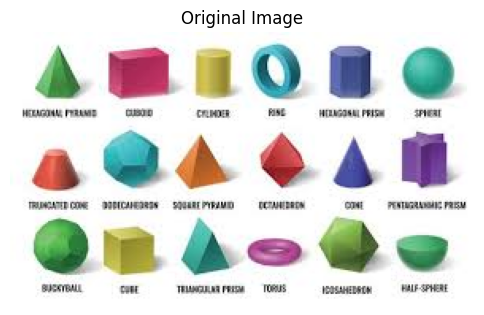

In [28]:
# Load image
image = cv.imread("../data/pictures/pics/shapes_2.jpeg")
rgb_image = cv.cvtColor(image, cv.COLOR_BGR2RGB)

# Display image
plt.figure(figsize=(6, 6))
plt.imshow(rgb_image)
plt.axis("off")
plt.title("Original Image")
plt.show()

## Image Preprocessing

Contour detection works best on binary images.  
Convert the image to grayscale and apply thresholding to separate foreground objects from the background.


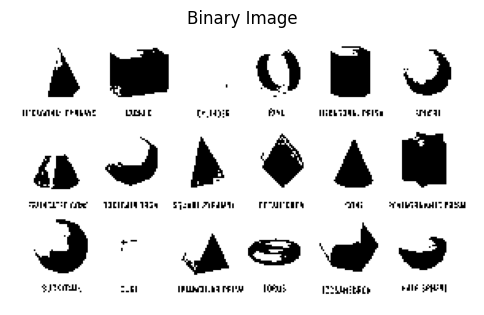

In [29]:
# Convert to grayscale
gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)

# Apply thresholding
_, binary = cv.threshold(gray, 127, 255, cv.THRESH_BINARY)

# Visualize binary image
plt.figure(figsize=(6, 6))
plt.imshow(binary, cmap='gray')
plt.axis('off')
plt.title('Binary Image')
plt.show()

## Detecting Contours

Contours represent the boundaries of objects in a binary image.
Using OpenCV's `findContours` function to extract these boundaries.

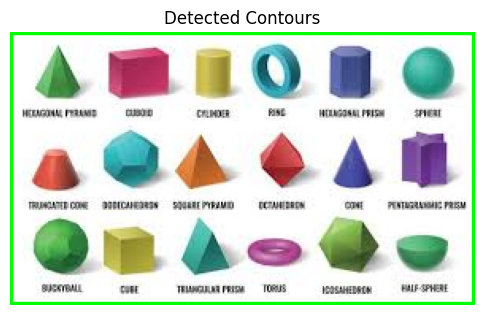

In [30]:
# Find contours
contours, _ = cv.findContours(
    binary,
    cv.RETR_EXTERNAL,
    cv.CHAIN_APPROX_SIMPLE
)

# Draw contours for visualization
contour_image = image.copy()
cv.drawContours(contour_image, contours, -1, (0, 255, 0), 2)

plt.figure(figsize=(6, 6))
plt.imshow(cv.cvtColor(contour_image, cv.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Detected Contours")
plt.show()

## Key notes:
- `RETR_EXTERNal` -> retrieves only outer contours
- `CHAIN_APPROX_SIMPLE` -> reduces memory usage by compressing points

## Approximating Contours

To recognize shapes, approximate each contour into a polygon using `approxPolyDP`. This reduces complex contours into simpler geometric forms.

In [31]:
def classify_shape(approx):
    vertices = len(approx)

    if vertices == 3:
        return "Triangle"
    elif vertices == 4:
        return "Quadrilateral"
    elif vertices > 4:
        return "Circle"
    else:
        return "Unknown"

## Shape Classification and Labeling

Loop through each detected contour, approximate its shape, classify it, and label the object directly on the image.

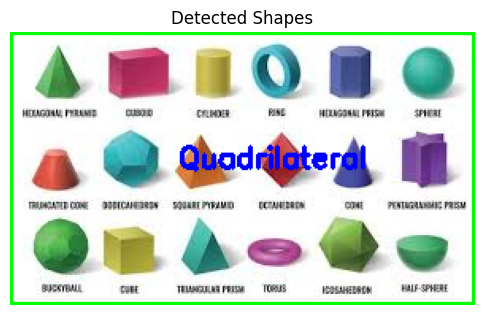

In [32]:
output =  image.copy()

for contour in contours:
    # Ignore very small contours (noise)
    if cv.contourArea(contour) < 500:
        continue

    # Approximate contour
    epsilon = 0.04 * cv.arcLength(contour, True)
    approx = cv.approxPolyDP(contour, epsilon, True)

    # Classify shape
    shape  = classify_shape(approx)

    # Compute centroid for labeling
    M = cv.moments(contour)
    if M["m00"] != 0:
        cx = int(M['m10'] / M['m00'])
        cy = int(M['m01'] / M['m00'])

        cv.putText(
            output,
            shape,
            (cx - 40, cy),
            cv.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255, 0, 0),
            2
        )

    # Draw approximated contour
    cv.drawContours(output, [approx], -1, (0, 255, 0), 2)


# Display final output
plt.figure(figsize=(6, 6))
plt.imshow(cv.cvtColor(output, cv.COLOR_BGR2RGB))
plt.axis('off')
plt.title("Detected Shapes")
plt.show()

## Key Findings

- Contours provide an effective way to represent object boundaries.
- Polygonal approximation simplifies contours while preserving shape structure.
- The number of polygon vertices can be used as a simple rule-based classifier.
- Thresholding quality directly affects contour detection accuracy.
- This method performs well for clean images with simple shapes but may struggle
  with noisy or overlapping objects.

## Conclusion

This notebook demonstrates a complete pipeline for contour detection and
shape recognition using OpenCV. By combining binary image processing,
contour extraction, and polygonal approximation, we successfully identified
and labeled basic geometric shapes in an image.

This project highlights the importance of geometric reasoning in classical
computer vision and serves as a foundation for more advanced object detection
and recognition systems.